# ImageNet 狗种类识别


In [1]:
import kagglehub
import torch
from torch import nn
import torchvision
import util
from pathlib import Path
import os
import pandas as pd
import numpy as np

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


获取数据

In [2]:
# Download latest version
path = Path('./data/dog-breed-identification')
util.data.reorg_data(path, 'labels.csv', 0.1)

sub_path = path/'submission.csv'
sub = pd.read_csv(sub_path)
sub['id'] = sub['id'].apply(lambda x: x.split('.')[0])
sub.to_csv(sub_path, index=False)

图片增广


In [3]:
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225])
test_aug = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256), # 调整图像大小为 256x256
    torchvision.transforms.CenterCrop(224), # 中心裁剪为 224x224
    torchvision.transforms.ToTensor(), # 转为张量
    normalize
])
train_aug = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(
        224,
        scale=(0.08, 1.0), # 切的小一点，练习识别局部特征
        ratio=(3.0 / 4.0, 4.0 / 3.0)
    ),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4
    ),
    torchvision.transforms.ToTensor(),
    normalize
])

读数据集


In [21]:
train_ds, train_valid_ds, valid_ds, test_ds = util.data.get_dataset(path, train_aug, test_aug)
train_iter, train_valid_iter, valid_iter, test_iter = util.data.get_dataloader(
    train_ds, train_valid_ds, valid_ds, test_ds,
    batch_size=256
)

预训练模型

In [5]:
# 因为是 ImageNet 的子集，所以固定原模型，添加一层
def get_net(devices):
    net = nn.Sequential()
    # features 是原模型，Sequential.xxx 可以直接访问或添加层
    net.features = torchvision.models.resnet34(weights=torchvision.models.ResNet34_Weights.DEFAULT)
    # output_new 是新加的层
    net.output_new = nn.Sequential(
        nn.Linear(1000, 256),
        nn.ReLU(),
        nn.Linear(256, 120)
    )
    # 固定原模型的参数
    for params in net.features.parameters():
        params.requires_grad = False
    net = net.to(devices[0])
    return net

计算损失


In [6]:
# reduction 指如何处理 batch 中的 loss，none 表示不处理，返回每个样本的 loss
loss = nn.CrossEntropyLoss(reduction="none")

def evaluate_loss(data_iter, net, devices):
    """计算在指定数据集上模型的损失"""
    l_sum, n = 0.0, 0
    for X, y in data_iter:
        X, y = X.to(devices[0]), y.to(devices[0])
        y_hat = net(X)
        l = loss(y_hat, y)
        l_sum += l.sum()
        n += y.numel()
    return float(l_sum / (n + 1e-8))

训练函数

In [7]:
def train(net,
          train_iter, valid_iter,
          num_epochs,
          lr, wd,
          devices,
          lr_period, lr_decay):
    """训练函数"""
    # 使用并行
    net = nn.DataParallel(net, devices).to(devices[0])
    # 训练器，只训练新层
    trainer = torch.optim.SGD([param for param in net.parameters() if param.requires_grad], lr=lr, weight_decay=wd)
    # 学习率调度器，每 lr_period 个 epoch 学习率乘以 lr_decay
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, step_size=lr_period, gamma=lr_decay)
    num_batches = len(train_iter)
    timer = util.Timer()
    legend = ['train loss', 'valid loss'] if valid_iter is not None else ['train loss']
    animator = util.Animator(xlabel='epoch', xlim=[1, num_epochs], legend=legend)
    for epoch in range(num_epochs):
        net.train()
        metric = util.Accumulator(2)
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            # 异步传输
            X, y = X.to(devices[0], non_blocking=True), y.to(devices[0], non_blocking=True)
            trainer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y).sum()
            l.backward()
            trainer.step()
            metric.add(l, y.shape[0])
            timer.stop()
            # 每个 epoch 画两次
            if (i + 1) % (num_batches // 2) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches, (metric[0] / metric[1], None))
        measures = f'train loss {metric[0] / metric[1]:.3f}'
        if valid_iter is not None:
            valid_loss = evaluate_loss(valid_iter, net, devices)
            animator.add(epoch + 1, (None, valid_loss))
        scheduler.step()
    if valid_iter is not None and valid_loss is not None:
        measures += f', valid loss {valid_loss:.3f}'
    print(measures + f'\n{metric[1] * num_epochs / timer.sum():.1f} examples/sec on {str(devices)}')

训练

train loss 1.020, valid loss 2.463
4741.3 examples/sec on [device(type='cuda', index=0)]


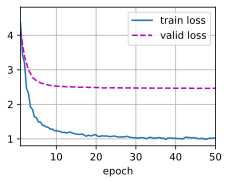

In [8]:
devices = util.try_all_gpus()
net = get_net(devices)
num_epochs = 50
lr = 1e-4
wd = 1e-4
lr_period = 2
lr_decay = 0.9
train(net,
      train_iter, valid_iter,
      num_epochs=num_epochs,
      lr=lr, wd=wd,
      devices=devices,
      lr_period=lr_period, lr_decay=lr_decay)

预测


In [28]:
train_iter, train_valid_iter, valid_iter, test_iter = util.data.get_dataloader(
    train_ds, train_valid_ds, valid_ds, test_ds,
    batch_size=256
)
def predict(net, test_iter):
    """预测函数"""
    preds = []
    with torch.no_grad():
        for X, _ in test_iter:
            X = X.to(devices[0])
            y_hat = net(X)
            # 提交时需要概率分布，所以使用 softmax
            y_hat = nn.functional.softmax(y_hat, dim=1)
            preds.append(y_hat.cpu().detach().numpy())
    ids = sorted(os.listdir(path / 'train_valid_test' / 'test' / 'unknown'))
    # 去掉 .jpg 后缀：Kaggle 要求的 id 列不含扩展名
    ids = [os.path.splitext(x)[0] for x in ids]
    classes = sorted(os.listdir(path / 'train_valid_test' / 'train'))
    id_df = pd.DataFrame({'id': ids})
    prob_df = pd.DataFrame(np.concatenate(preds, axis=0), columns=classes)
    df = pd.concat([id_df, prob_df], axis=1)
    df.to_csv(path / 'submission.csv', index=False)
predict(net, test_iter)